# ResNet18 Transfer Learning Analysis

## Objective

This notebook analyzes the impact of transfer learning strategies
for brain tumor MRI classification.

Two ResNet18 approaches are compared:

1. Feature Extraction
    - ImageNet pretrained backbone frozen
    - Only classifier trained

2. Fine-Tuning
    - Higher-level ResNet layers unfrozen
    - Backbone adapted to MRI domain

The goal is to evaluate whether fine-tuning improves
performance under domain shift between ImageNet and medical MRI images.

## IMPORTS

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

## PATHS

In [2]:
PROJECT_ROOT = Path("../")


FEATURE_EXTRACTION = (
    PROJECT_ROOT
    /
    "experiments"
    /
    "resnet18_transfer_learning"
)


FINETUNE = (
    PROJECT_ROOT
    /
    "experiments"
    /
    "resnet18_finetune"
)


print(FEATURE_EXTRACTION)
print(FINETUNE)

../experiments/resnet18_transfer_learning
../experiments/resnet18_finetune


## HELPER LOADER FUNCTION

In [3]:
def load_json(path):

    with open(path) as f:
        return json.load(f)



def load_experiment(exp_dir):

    history = load_json(
        exp_dir /
        "logs" /
        "training_history.json"
    )


    metrics = load_json(
        exp_dir /
        "results" /
        "metrics.json"
    )


    confusion_matrix = np.load(
        exp_dir /
        "results" /
        "confusion_matrix.npy"
    )


    predictions = pd.read_csv(
        exp_dir /
        "results" /
        "predictions.csv"
    )


    return {
        "history": history,
        "metrics": metrics,
        "confusion_matrix": confusion_matrix,
        "predictions": predictions,
    }

## LOAD EXPERIMENTS

In [4]:
fe = load_experiment(FEATURE_EXTRACTION)

ft = load_experiment(FINETUNE)


print("feature extraction loaded ✓")
print("finetune loaded ✓")

feature extraction loaded ✓
finetune loaded ✓


## 1.Test Performance Comparison

In [5]:
comparison = pd.DataFrame(
    {
        "Feature Extraction": fe["metrics"],
        "Finetune": ft["metrics"],
    }
)


comparison

,Feature Extraction,Finetune
accuracy,0.818043,0.977829
precision,0.820544,0.980388
recall,0.818925,0.979988
f1,0.818825,0.980113
loss,0.457776,0.066127


## IMPROVEMENT CALCULATION

In [6]:
improvement = pd.DataFrame(
    {
        "Absolute Improvement":
        comparison["Finetune"]
        -
        comparison["Feature Extraction"],


        "Relative Improvement (%)":
        (
            (
                comparison["Finetune"]
                -
                comparison["Feature Extraction"]
            )
            /
            comparison["Feature Extraction"]
        )
        *
        100
    }
)


improvement

,Absolute Improvement,Relative Improvement (%)
accuracy,0.159786,19.532710
precision,0.159844,19.480220
recall,0.161062,19.667492
f1,0.161288,19.697480
loss,-0.391650,-85.554795


## 2.Training & Validation Curves¶

### Compare convergence behavior.

### Questions:

    Which model learns faster?
    Which model is more stable?
    Is there evidence of overfitting?


## TRAINING LOSS

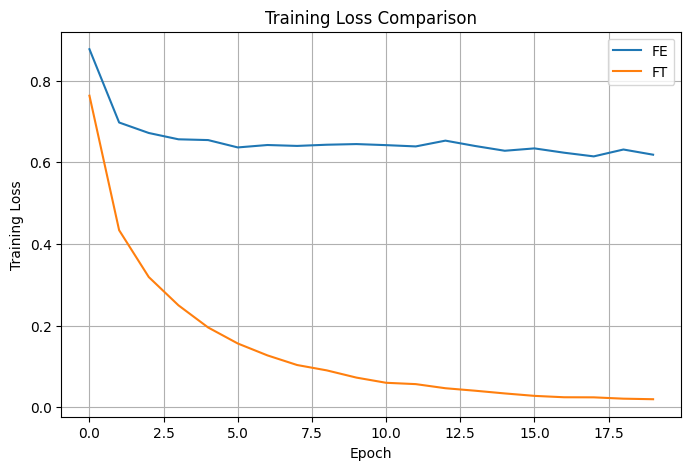

In [8]:
plt.figure(figsize=(8,5))


plt.plot(
    fe["history"]["train_loss"],
    label="FE"
)


plt.plot(
    ft["history"]["train_loss"],
    label="FT"
)


plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "Training Loss Comparison"
)

plt.legend()

plt.grid()

plt.show()

## VALIDATION LOSS

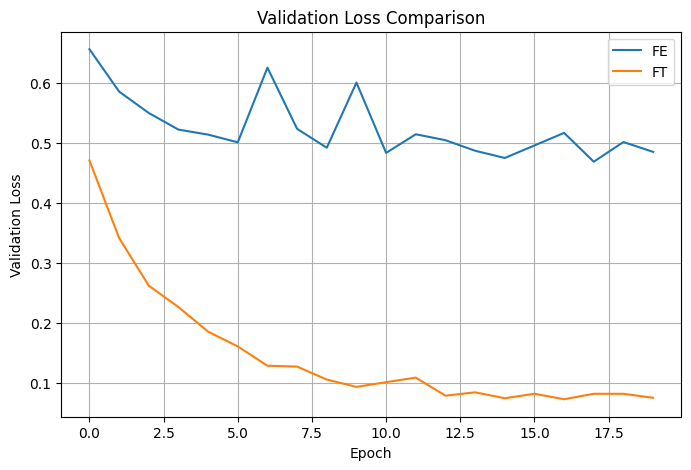

In [9]:
plt.figure(figsize=(8,5))


plt.plot(
    fe["history"]["val_loss"],
    label="FE"
)


plt.plot(
    ft["history"]["val_loss"],
    label="FT"
)


plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title(
    "Validation Loss Comparison"
)


plt.legend()

plt.grid()

plt.show()

## TRAINING ACCURACY

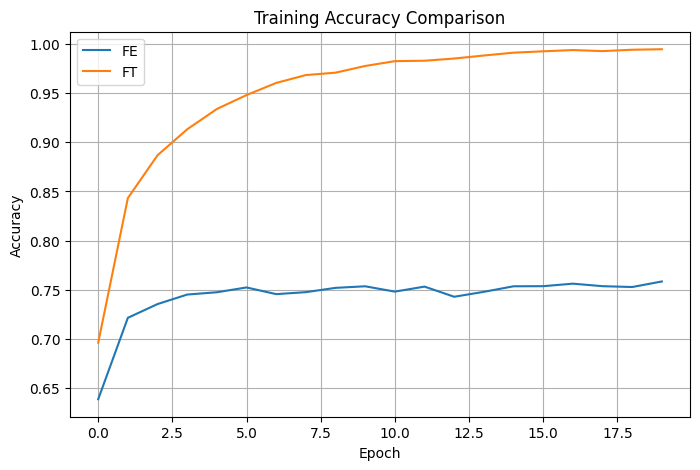

In [10]:
plt.figure(figsize=(8,5))


plt.plot(
    fe["history"]["train_accuracy"],
    label="FE"
)


plt.plot(
    ft["history"]["train_accuracy"],
    label="FT"
)


plt.xlabel("Epoch")
plt.ylabel("Accuracy")


plt.title(
    "Training Accuracy Comparison"
)


plt.legend()

plt.grid()

plt.show()

## VALIDATION ACCURACY

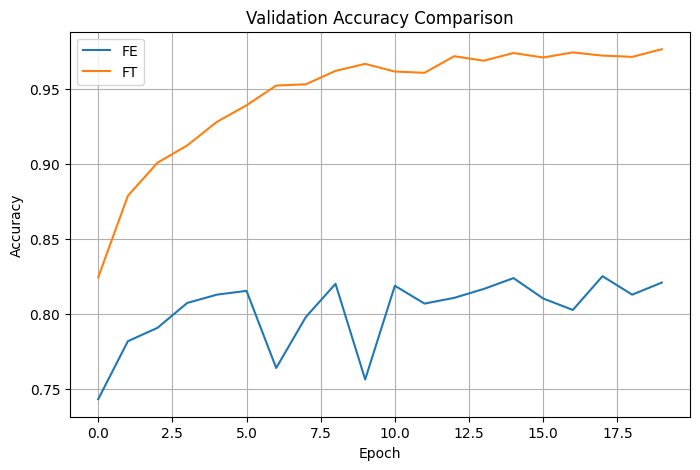

In [11]:
plt.figure(figsize=(8,5))


plt.plot(
    fe["history"]["val_accuracy"],
    label="FE"
)


plt.plot(
    ft["history"]["val_accuracy"],
    label="FT"
)


plt.xlabel("Epoch")
plt.ylabel("Accuracy")


plt.title(
    "Validation Accuracy Comparison"
)


plt.legend()

plt.grid()

plt.show()

## 3.Confusion Matrix comparison

## Normalized confusion matrices show class-level recall.

This helps identify:

    dominant classes
    difficult classes
    systematic confusion


## Feature Extraction Confusion Matrix

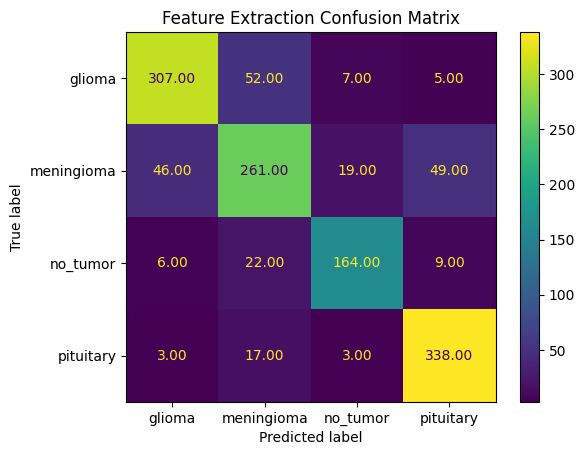

In [12]:
class_names = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]


disp = ConfusionMatrixDisplay(
    confusion_matrix=fe["confusion_matrix"],
    display_labels=class_names
)


disp.plot(
    values_format=".2f"
)


plt.title(
    "Feature Extraction Confusion Matrix"
)

plt.show()

## Finetune Confusion Matrix

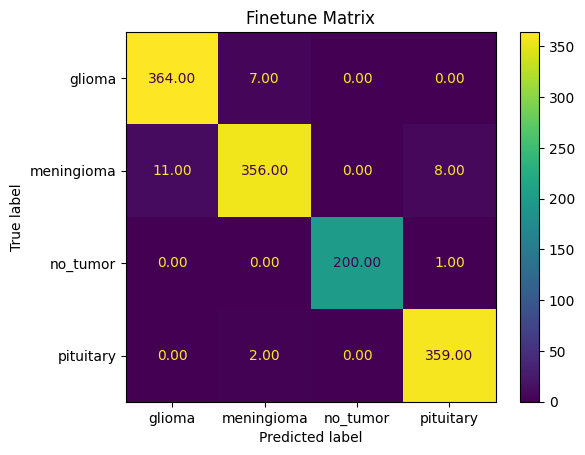

In [19]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=ft["confusion_matrix"],
    display_labels=class_names
)


disp.plot(
    values_format=".2f"
)


plt.title(
    "Finetune Matrix"
)

plt.show()

## 4.Error Rate Comparison

In [15]:
fe_errors = (
    fe["predictions"]["true_label"]
    !=
    fe["predictions"]["predicted_label"]
).sum()



ft_errors = (
    ft["predictions"]["true_label"]
    !=
    ft["predictions"]["predicted_label"]
).sum()



error_comparison = pd.DataFrame(
    {
        "Model":
        [
            "Feature Extraction",
            "Finetune"
        ],

        "Errors":
        [
            fe_errors,
            ft_errors
        ]
    }
)


error_comparison

,Model,Errors
0,Feature Extraction,238
1,Finetune,29


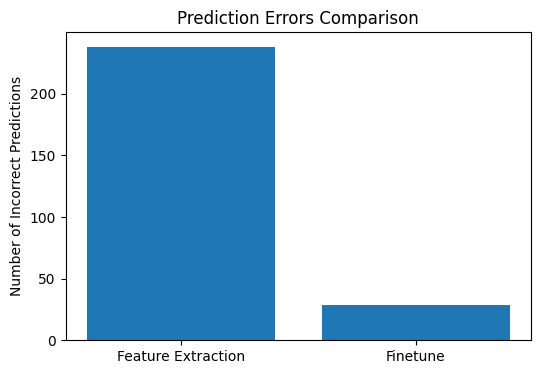

In [16]:
plt.figure(figsize=(6,4))


plt.bar(
    error_comparison["Model"],
    error_comparison["Errors"]
)


plt.title(
    "Prediction Errors Comparison"
)


plt.ylabel(
    "Number of Incorrect Predictions"
)


plt.show()

## 5.Prediction distribution Analysis

In [18]:
pred_distribution = pd.DataFrame(
    {
        "Feature Extraction":
        fe["predictions"]["predicted_label"].value_counts(),

        "Finetune":
        ft["predictions"]["predicted_label"].value_counts(),
    }
)


pred_distribution

,Feature Extraction,Finetune
predicted_label,,
0,362,375
1,352,365
2,193,200
3,401,368


# Conclusion

This experiment compared two transfer learning strategies using a pretrained ResNet18 backbone:

1. Feature Extraction:
   - The pretrained ResNet18 backbone was frozen.
   - Only the final classification layer was trained on the brain tumor MRI dataset.

2. Fine-Tuning:
   - The final ResNet18 residual block (`layer4`) and classifier were unfrozen.
   - The pretrained representation was adapted to the MRI domain using a smaller learning rate.

---

## Performance Comparison

The feature extraction approach achieved:

- Accuracy: 81.80%
- Precision: 82.05%
- Recall: 81.89%
- F1-score: 81.88%
- Loss: 0.458

After fine-tuning, performance improved significantly:

- Accuracy: 97.78%
- Precision: 98.04%
- Recall: 98.00%
- F1-score: 98.01%
- Loss: 0.066

Fine-tuning improved accuracy by approximately **15.98 percentage points**, representing a relative improvement of **19.53%** compared with frozen feature extraction.

The number of incorrect predictions decreased:

- Feature Extraction errors: 238
- Fine-tuned ResNet18 errors: 29

---

## Interpretation

The large improvement demonstrates the importance of adapting pretrained features to the target domain.

Although ImageNet pretrained models provide useful low-level visual features, a frozen backbone cannot fully capture the characteristics of brain MRI images because of the domain difference between natural images and medical imaging data.

By allowing deeper ResNet layers to update during training, the model learned MRI-specific representations and significantly improved classification performance.

---

## Model Selection Decision

The fine-tuned ResNet18 model is selected as the preferred transfer learning model because it provides:

- Higher classification accuracy.
- Better precision and recall.
- Lower validation/test loss.
- Fewer classification errors.

The experiment confirms that fine-tuning pretrained convolutional networks is substantially more effective than using them only as fixed feature extractors for this medical imaging task.

The fine-tuned ResNet18 will be used as the final deep learning model for comparison against the custom CNN baselines.